In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv('../data/raw/apple_products_pricing_2020_2026.csv') 

In [4]:
print(df.shape)

(80000, 14)


In [9]:
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  str    
 1   Platform           80000 non-null  str    
 2   Product_Category   80000 non-null  str    
 3   Model_Name         80000 non-null  str    
 4   Condition          80000 non-null  str    
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   str    
 11  Stock_Status       80000 non-null  str    
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), str(7)
memory usage: 8.5 MB


In [23]:
# Convert Date column to datetime instead of String
df['Date'] = pd.to_datetime(df['Date'])

0   2020-09-19
1   2020-09-20
2   2020-09-23
3   2020-09-23
4   2020-09-24
Name: Date, dtype: datetime64[us]

In [10]:
df.describe()

,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Rating,Reviews_Count
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,963.959125,94467.994250,782.769855,74628.342439,21.418826,4.450099,2405.995925
std,470.086413,46068.468464,461.673970,45117.872172,16.697310,0.269782,1973.630852
min,329.000000,32242.000000,109.930000,9157.680000,-2.000000,3.800000,10.000000
25%,599.000000,58702.000000,432.930000,41686.835000,6.700000,4.300000,896.000000
50%,799.000000,78302.000000,699.740000,67324.020000,21.300000,4.400000,1893.500000
75%,1199.000000,117502.000000,989.112500,96568.117500,36.800000,4.700000,3383.000000
max,1999.000000,195902.000000,2038.970000,203668.710000,73.100000,4.900000,11526.000000


In [11]:
df.describe(include='object')

/var/folders/hd/rg1pd_9n27l1j1s6_8hcl6rm0000gn/T/ipykernel_15869/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Date,Platform,Product_Category,Model_Name,Condition,Sale_Event,Stock_Status
count,80000,80000,80000,80000,80000,6649,80000
unique,2130,2,4,31,2,4,3
top,2025-06-11,Flipkart,iPhone,iPhone 14 Pro 128GB,New,Black Friday,In Stock
freq,95,40043,28589,2734,59985,2497,55034


In [12]:
print(df.nunique())

Date                  2130
Platform                 2
Product_Category         4
Model_Name              31
Condition                2
Launch_Price_USD         9
Launch_Price_INR         9
Current_Price_USD    49611
Current_Price_INR    79626
Discount_Pct           695
Sale_Event               4
Stock_Status             3
Rating                  12
Reviews_Count         8698
dtype: int64


In [14]:
# Count and percentage of missing values
missing = pd.DataFrame({
    'count':   df.isnull().sum(),
    'percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('percent', ascending=False)
print(missing[missing['count'] > 0])

            count  percent
Sale_Event  73351    91.69


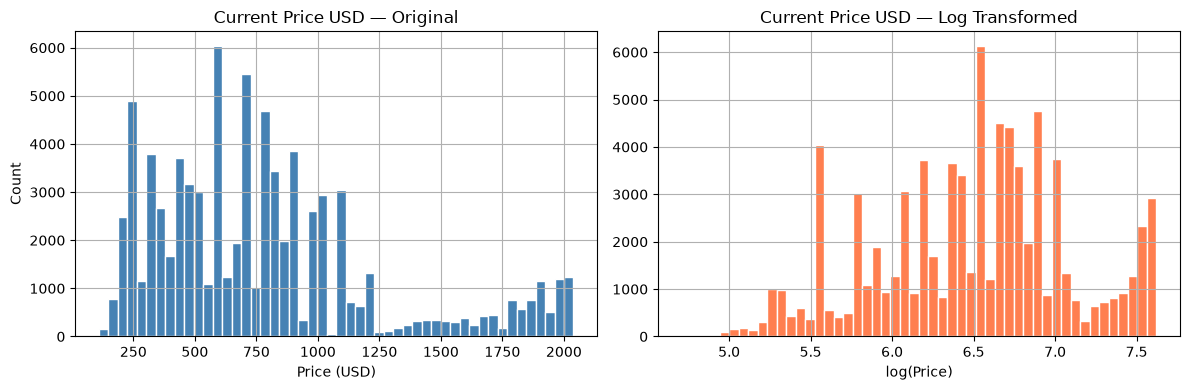

Skewness (original):        1.110
Skewness (log-transformed): -0.164
count    80000.000000
mean       782.769855
std        461.673970
min        109.930000
25%        432.930000
50%        699.740000
75%        989.112500
max       2038.970000
Name: Current_Price_USD, dtype: float64


In [18]:
# Step 1 — plot the raw distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Current_Price_USD'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Current Price USD — Original')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

# Step 2 — plot log-transformed version side by side
np.log1p(df['Current_Price_USD']).hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Current Price USD — Log Transformed')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

# Step 3 — check skewness
print(f"Skewness (original):        {df['Current_Price_USD'].skew():.3f}")
print(f"Skewness (log-transformed): {np.log1p(df['Current_Price_USD']).skew():.3f}")

# Step 4 — basic stats
print(df['Current_Price_USD'].describe())


The $109 minimum and $2,038 maximum suggest the dataset covers the full Apple product range — from accessories or older entry-level devices up to current Pro models. The max of $2,038 being well below what a maxed-out Mac Pro actually costs ($6,000+) suggests either the dataset caps at a certain tier, or it's using older pricing data.

The IQR (Q3 - Q1 = $989 - $432 = $557) is quite wide — meaning price varies significantly across the middle 50% of products. This is actually good for your model — it means there's real variation to learn from, not everything clustered at one price point.

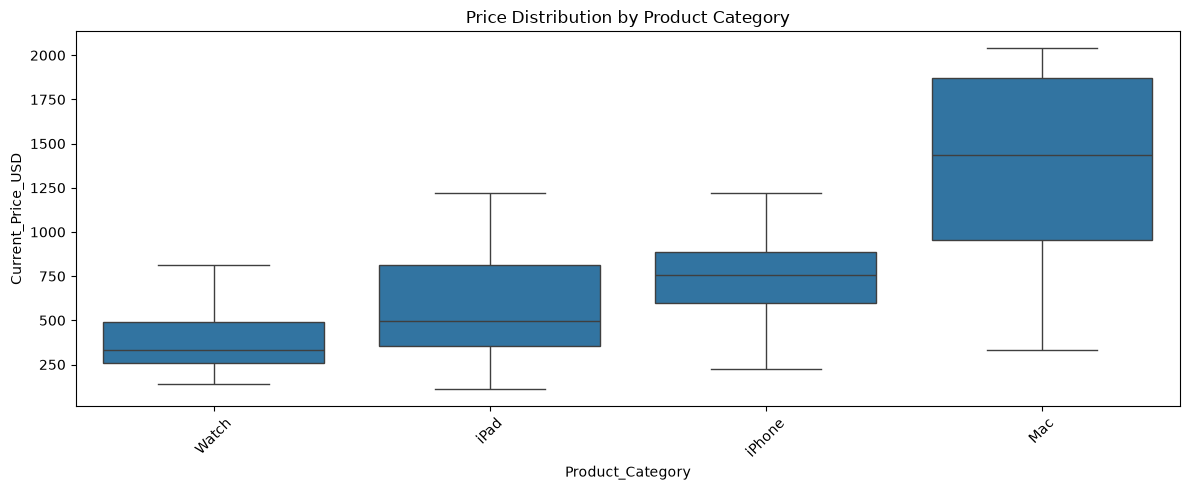

In [20]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='Product_Category', y='Current_Price_USD', data=df)
plt.title('Price Distribution by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

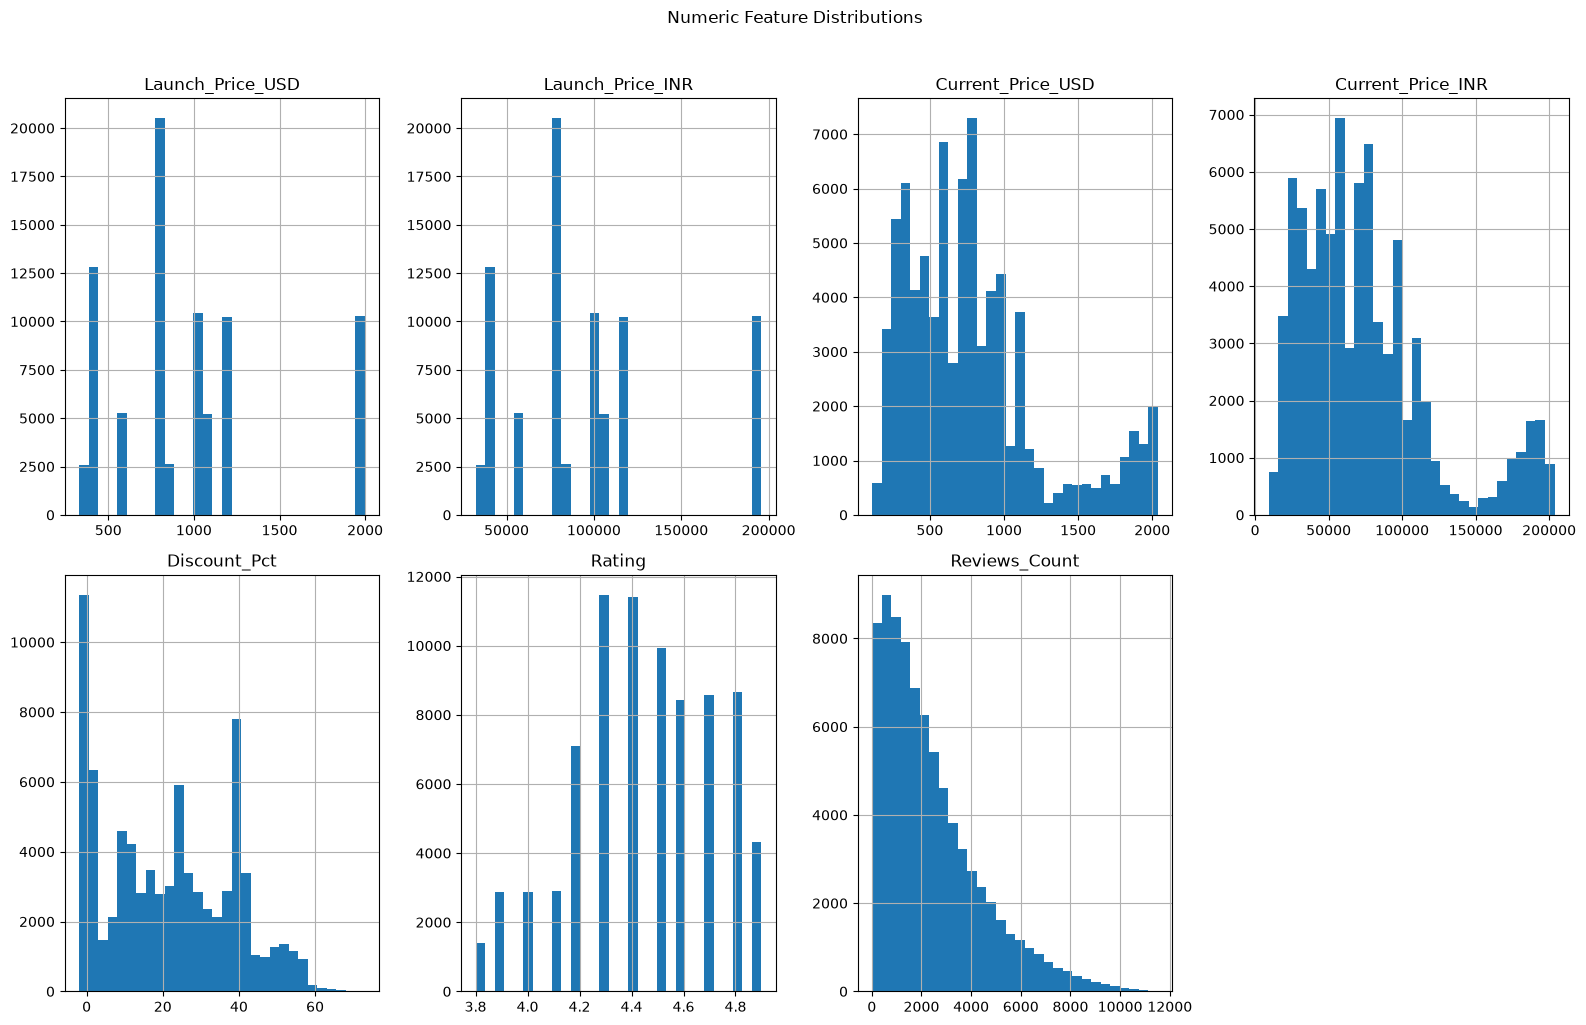

In [21]:
# Plot all numeric distributions at once
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(bins=30, figsize=(16, 10), layout=(-1, 4))
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))




Platform — 2 unique values
Platform
Flipkart    40043
Amazon      39957
Name: count, dtype: int64

Product_Category — 4 unique values
Product_Category
iPhone    28589
Mac       18020
Watch     17865
iPad      15526
Name: count, dtype: int64

Model_Name — 31 unique values
Model_Name
iPhone 14 Pro 128GB                 2734
iPad Air (4th Gen) 64GB             2677
iPad Pro 11-inch (M1) 128GB         2661
iPhone 17 128GB                     2652
iPhone 16 Pro 256GB                 2635
MacBook Pro 14-inch M4 Pro 512GB    2623
MacBook Air M2 256GB                2610
Apple Watch Series 8 (45mm)         2606
iPhone 13 128GB                     2605
iPhone 12 Pro 128GB                 2604
Name: count, dtype: int64

Condition — 2 unique values
Condition
New                    59985
Renewed/Refurbished    20015
Name: count, dtype: int64

Sale_Event — 4 unique values
Sale_Event
Black Friday             2497
Big Billion Days         1579
Great Indian Festival    1504
Prime Day                1

/var/folders/hd/rg1pd_9n27l1j1s6_8hcl6rm0000gn/T/ipykernel_15869/1932680516.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()
